In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Introduction

If you are here, then you **have most probably a broken heart** because your best models are not even close to the **0.05** and you have searched the galaxy for all the hyper parameters.

Now, you realize that other high performing notebooks have applied thresholds to clip the proababilities but are very **risky** at the same time. So, why not apply a function to visualize the kind of improvement you can get by thresholding alongwith a safe margin of your choice to prevent a massive test shakeup.

This notebook is a very simple visualization and function to provide you with the thresholds based on your own models. Its inputs are 

* y_true : The True labels
* Predicted Class=1 Probabilities : The probabilities only for the Class_1 coming from your current model
* Chosen Safe_limit : A safety margin. (See the picture below to understand more.) 
    * Safe_limit = 1. Means that we will select the probability which was the border of the worst class_1 prediction for an opposite class. Highest risk of overfit/shakeup
    * Safe_limit > 1. Means that we will buffer and only change the probabilities which are at a distance from the model's worst prediction
    * Safe_limit < 1. Means we will reduce the performance of the model as we will be breaching the model's own boundaries
    
    
**Based on my results, I would recommend a safe_limit of 1.5 or higher atleast. But I dont have scientific evidence to back it up**

## Helper Functions

* Just copy in your own notebook's beginning code cells

In [2]:
# Helper Functions
####################################################################################################################################
####################################################################################################################################
def balanced_log_loss(y_true, y_pred):
    # y_true: correct labels 0, 1
    # y_pred: predicted probabilities of class=1
    # calculate the number of observations for each class
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    # calculate the weights for each class to balance classes
    w_0 = 1 / N_0
    w_1 = 1 / N_1
    # calculate the predicted probabilities for each class
    p_1 = np.clip(y_pred, 1e-15, 1 - 1e-15)
    p_0 = 1 - p_1
    # calculate the summed log loss for each class
    log_loss_0 = -np.sum((1 - y_true) * np.log(p_0))
    log_loss_1 = -np.sum(y_true * np.log(p_1))
    # calculate the weighted summed logarithmic loss
    # (factgor of 2 included to give same result as LL with balanced input)
    balanced_log_loss = 2*(w_0 * log_loss_0 + w_1 * log_loss_1) / (w_0 + w_1)
    # return the average log loss
    return balanced_log_loss/(N_0+N_1)

####################################################################################################################################
####################################################################################################################################

def threshold_tuner(y_true,
                    predict_proba_class_1,
                    safe_limit = 2,
                    plots = True
                   ):


    dddf = pd.DataFrame(y_true)
    dddf["class_1_prob"] = predict_proba_class_1
    dddf.columns = ["true", "class_1_prob"]
    dddf = dddf.sort_values(by="true")
    dddf["Y"] = dddf["true"].apply(lambda x : np.random.randint(500)) #Just a random number.

    safe_upper_limit = 1 - (1 - (dddf[dddf["true"] == 0]["class_1_prob"].max())) / safe_limit
    safe_lower_limit = dddf[dddf["true"] == 1]["class_1_prob"].min() / safe_limit
    
    if plots:
        plt.scatter(y = dddf[dddf["true"] == 0]["class_1_prob"],
                    x = dddf[dddf["true"] == 0]["Y"],
                    alpha = 0.5,
                    marker = 'o',
                    label = 'True=0'
                   )
        plt.scatter(y = dddf[dddf["true"] == 1]["class_1_prob"],
                    x = dddf[dddf["true"] == 1]["Y"],
                    alpha = 0.5,
                    marker = 'o',
                    label = 'True=1'
                   )
        plt.title("Class 1 Probabilities vs. True Labels")
        plt.legend(loc='best')
        plt.axhline(safe_lower_limit, c = 'r')
        plt.axhline(safe_upper_limit, c = 'b')
        plt.show()
    
    print("Balanced log loss : Without thresholding {}".format( balanced_log_loss( y_true = y_true,
                                                                                 y_pred= predict_proba_class_1
                                                                                 )))
    thr_c1 = predict_proba_class_1.copy()
    thr_c1[thr_c1 < safe_lower_limit] = 0.0
    thr_c1[thr_c1 > safe_upper_limit] = 1.0
    
    print("Balanced log loss : After thresholding {}".format( balanced_log_loss( y_true = y_true,
                                                                                y_pred=thr_c1)))
    
    res = []
    res.append({"SL" : 0, "loss" : balanced_log_loss( y_true = y_true, y_pred= predict_proba_class_1)})
    
    for SL in np.arange(1, 4, 0.1):
        sl_upper = 1 - (1 - (dddf[dddf["true"] == 0]["class_1_prob"].max())) / SL
        sl_lower = dddf[dddf["true"] == 1]["class_1_prob"].min() / SL
        thr_c1 = predict_proba_class_1.copy()
        thr_c1[thr_c1 < sl_lower] = 0.0
        thr_c1[thr_c1 > sl_upper] = 1.0
        res.append({"SL" : SL,
                    "loss" : balanced_log_loss( y_true = y_true, y_pred=thr_c1)
                   })
        
    return safe_lower_limit, safe_upper_limit, res

####################################################################################################################################
####################################################################################################################################

def get_safetylimit_vs_loss(results):
    results = pd.DataFrame(results)
    plt.scatter(results[results["SL"] != 0]["SL"], results[results["SL"] != 0]["loss"])
    plt.axhline(results[results["SL"] == 0]["loss"].values[0], c='r')
    plt.title("Red Line = No Thresholding. Dots are scores with safelimit on x-axis ")
    plt.xlabel("Safe Limit")
    plt.ylabel("Balanced Log Loss")
    plt.show()
    
####################################################################################################################################
####################################################################################################################################

def get_safe_thresholds(y_true,
                        class_1_p,
                        safe_limit = 1.75,
                        plots = True):
    '''
        Tries to provide the thresholds for improving the scores on log-loss based on the provided true labels and the class 1 probabilities.
        y_true : The true labels. Must be 0 or 1
        predict_proba_class_1 : ONLY THE PROBS of CLASS 1 should be passed here        
        safe_limit : If the limit is 2, then the thresholds would be half-distance between the worst predicted probability
                        and the true probability limit. 
                        If safe_limit == 1, then it will be most overfit. 
                        If safe_limit < 1 would be worst than current performance. 
                        If safe_limit > 1 would mean safer thresholding.
    
    '''
    a, b, c = threshold_tuner(y_true = y_true,
                                predict_proba_class_1 = class_1_p,
                                safe_limit= safe_limit,
                                plots = plots)

    if plots:
        get_safetylimit_vs_loss(c)
    
    print("*"*80)
    print("Based on the safelimit {}, change your predictions threshold like below. ".format(safe_limit))
    print("\r\n\t\tpred_class_1[ pred_class_1 > {} ] = 1.0".format(np.round(b, 5)))
    print("\t\tpred_class_1[ pred_class_1 < {} ] = 0.0".format(np.round(a, 5)))
    print("*"*80)
    
    print("CAUTION : Take note of the greater than and less than signs. These are not >= or <= but just > and <")
    return a, b

# Example Usage

* I am loading a file with probabilities of Class_1 on the training set from a dummy classifier
* I will then use the function to see what should be the upper and lower limit for thresholding for this classifier and the gains observed

In [3]:
df = pd.read_csv("/kaggle/input/icr-example-probabilities/example_probabilities.csv")
df.head(2)

,class_1_p,true
0,0.824653,1
1,0.003764,0


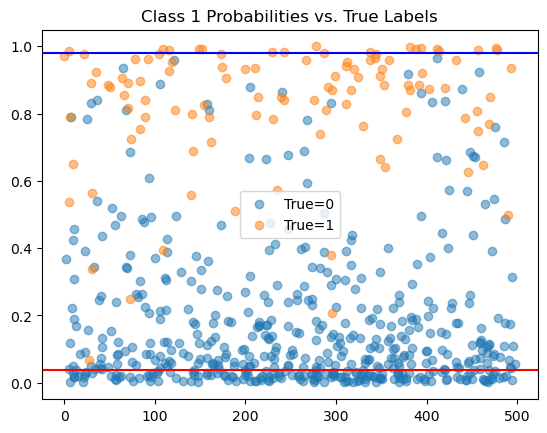

Balanced log loss : Without thresholding 0.14146866027415006
Balanced log loss : After thresholding 0.13932665585660156


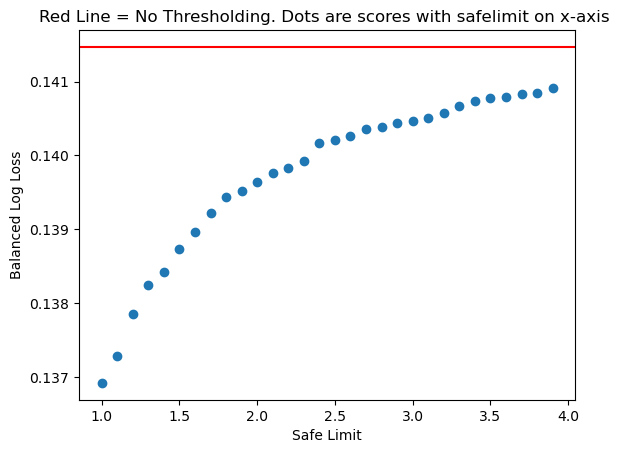

********************************************************************************
Based on the safelimit 1.75, change your predictions threshold like below. 

		pred_class_1[ pred_class_1 > 0.97923 ] = 1.0
		pred_class_1[ pred_class_1 < 0.03921 ] = 0.0
********************************************************************************
CAUTION : Take note of the greater than and less than signs. These are not >= or <= but just > and <


In [4]:
lower, upper = get_safe_thresholds(y_true = df["true"].values,
                        class_1_p = df["class_1_p"].values,
                        safe_limit = 1.75,
                        plots = True)

---

# That's All Folks

* Redline in the chart shows the original balanced_log_loss without any thresholding
* The dots show the score in comparison to a chosen Safe_limit

* Once you decide a safelimit (like  1.5 or 1.75 etc...), then run the function to get your lower and upper thresholds
```
    get_safe_thresholds(y_true = df["true"].values,
                        class_1_p = df["class_1_p"].values,
                        safe_limit = <CHOSEN SAGE LIMIT HERE>,
                        plots = True)
```

---

Use the information printed for the thresholds. The chart shows the predicted score on the same dataset based on the chosen safe_limit.

**Remember** : Safe_limit close to 1 is riskier. Higher than 1 is less risky....

In [5]:
print("Obtained thresholds are {}, {}".format(lower, upper))

Obtained thresholds are 0.03920637428873892, 0.9792269818443131
